# Chapter 4 — Training Linear Models

> *Hands-On Machine Learning with Scikit-Learn, Keras & PyTorch* — Aurélien Géron (2025)

---

In [1]:
import sys
import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Scikit-Learn
from sklearn.linear_model import (LinearRegression, SGDRegressor, Ridge,
                                   Lasso, ElasticNet, LogisticRegression)
from sklearn.preprocessing import (PolynomialFeatures, StandardScaler,
                                    add_dummy_feature)
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import learning_curve, cross_val_score
from sklearn.datasets import load_iris, make_regression
from sklearn.metrics import root_mean_squared_error

# Reproducibility
np.random.seed(42)

# Shared data path — works from any chapter subfolder
DATA_PATH = Path('../data')

# Resumen: Modelo de Regresión Lineal

## 1. Modelo lineal simple (una característica)

La satisfacción de vida se modela como una función lineal del PIB per cápita:

$$
\text{life\_satisfaction} = \theta_0 + \theta_1 \times \text{GDP\_per\_capita}
$$

Donde $\theta_0$ y $\theta_1$ son los **parámetros del modelo**.

## 2. Modelo de regresión lineal general (múltiples características)

La predicción $\hat{y}$ se calcula como una suma ponderada de las características de entrada más un sesgo (intercepto):

$$
\hat{y} = \theta_0 + \theta_1 x_1 + \theta_2 x_2 + \cdots + \theta_n x_n
$$

- $\hat{y}$ : valor predicho.
- $n$ : número de características.
- $x_i$ : valor de la $i$-ésima característica.
- $\theta_j$ : $j$-ésimo parámetro del modelo ($\theta_0$ es el sesgo, $\theta_1 \dots \theta_n$ son los pesos).

## 3. Forma vectorizada

El modelo puede escribirse de manera compacta usando el producto punto:

$$
\hat{y} = h_\theta(\mathbf{x}) = \boldsymbol{\theta} \cdot \mathbf{x}
$$

- $h_\theta$ : función de hipótesis parametrizada por $\boldsymbol{\theta}$.
- $\boldsymbol{\theta}$ : vector de parámetros $[\theta_0, \theta_1, \dots, \theta_n]$.
- $\mathbf{x}$ : vector de características $[x_0, x_1, \dots, x_n]$, **con $x_0 = 1$ siempre**.
- $\boldsymbol{\theta} \cdot \mathbf{x}$ : producto punto igual a $\theta_0 x_0 + \theta_1 x_1 + \cdots + \theta_n x_n$.

La función a minimizar MSE (Mean Squared Error) se define como:
$$
J(\boldsymbol{\theta}) = \frac{1}{m} \sum_{i=1}^{m} (h_\theta(\mathbf{x}^{(i)}) - y^{(i)})^2
$$

## The Normal Equation

La solución analítica para encontrar los parámetros $\boldsymbol{\theta}$ que minimizan la función de costo MSE es dada por la **Ecuación Normal**:
$$
\boldsymbol{\theta} = (\mathbf{X}^T \mathbf{X})^{-1} \mathbf{X}^T \mathbf{y}
$$

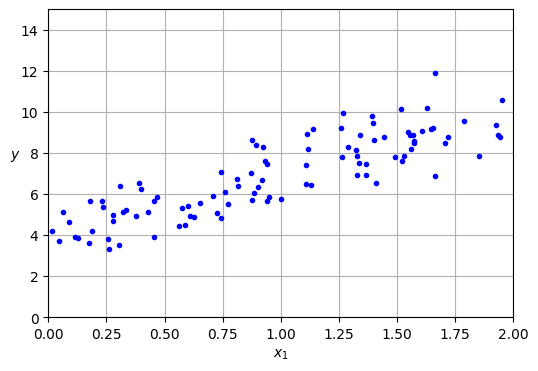

In [2]:
import numpy as np

rng = np.random.default_rng(42)
m = 100
X = 2 * rng.random((m, 1))
y = 4 + 3 * X + rng.standard_normal((m, 1)) # y = 4 + 3X + ruido gaussiano

# extra code – generates Figure 4–1

import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.plot(X, y, "b.")
plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.axis([0, 2, 0, 15])
plt.grid()

plt.show()

In [3]:
from sklearn.preprocessing import add_dummy_feature

X_b = add_dummy_feature(X)  # agrega una columna de 1s para el término de sesgo
theta_best = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y
theta_best

array([[3.94869973],
       [3.03831479]])

In [4]:
X_new = np.array([[0], [2]])
X_new_b = add_dummy_feature(X_new)
y_predict = X_new_b @ theta_best
y_predict

array([[ 3.94869973],
       [10.02532931]])

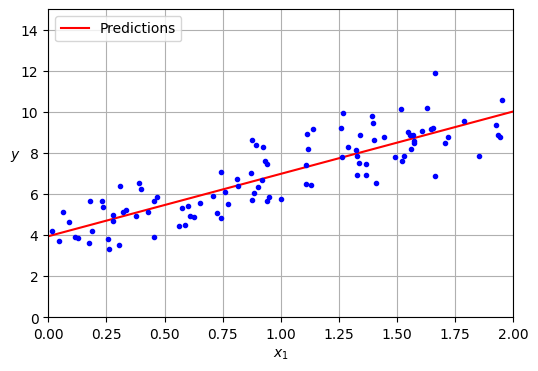

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))  # extra code – not needed, just formatting
plt.plot(X_new, y_predict, "r-", label="Predictions")
plt.plot(X, y, "b.")

# extra code – beautifies Figure 4–2
plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.axis([0, 2, 0, 15])
plt.grid()
plt.legend(loc="upper left")

plt.show()

In [6]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X, y)
lr.intercept_, lr.coef_

(array([3.94869973]), array([[3.03831479]]))

In [7]:
lr.predict(X_new)

array([[ 3.94869973],
       [10.02532931]])

The `LinearRegression` class is based on the `scipy.linalg.lstsq()` function (the name stands for "least squares"), which you could call directly:

In [8]:
theta_best_svd, residuals, rank, s = np.linalg.lstsq(X_b, y, rcond=1e-6)
theta_best_svd

array([[3.94869973],
       [3.03831479]])

This function computes $\mathbf{X}^+\mathbf{y}$, where $\mathbf{X}^{+}$ is the _pseudoinverse_ of $\mathbf{X}$ (specifically the Moore-Penrose inverse). You can use `np.linalg.pinv()` to compute the pseudoinverse directly:

In [9]:
np.linalg.pinv(X_b) @ y

array([[3.94869973],
       [3.03831479]])

# Gradient Descent
## Batch Gradient Descent

Para cada parámetro $\theta_j$ se necesita la **derivada parcial** de la función de costo (MSE) respecto a $\theta_j$:

$$
\frac{\partial}{\partial \theta_j} \text{MSE}(\boldsymbol{\theta}) = \frac{2}{m} \sum_{i=1}^{m} \left( \boldsymbol{\theta}^\top \mathbf{x}^{(i)} - y^{(i)} \right) x_j^{(i)}
\qquad (4\text{-}6)
$$

El **vector gradiente** agrupa todas las derivadas parciales:

$$
\nabla_{\boldsymbol{\theta}} \text{MSE}(\boldsymbol{\theta}) = 
\begin{bmatrix}
\frac{\partial}{\partial \theta_0} \text{MSE}(\boldsymbol{\theta}) \\
\frac{\partial}{\partial \theta_1} \text{MSE}(\boldsymbol{\theta}) \\
\vdots \\
\frac{\partial}{\partial \theta_n} \text{MSE}(\boldsymbol{\theta})
\end{bmatrix}
= \frac{2}{m} \mathbf{X}^\top (\mathbf{X}\boldsymbol{\theta} - \mathbf{y})
\qquad (4\text{-}7)
$$

- La derivada parcial mide el cambio de la función al modificar ligeramente $\theta_j$.
- El gradiente apunta en la dirección de máximo crecimiento; se usa con signo contrario para descender.


El siguiente paso de actualización se realiza para cada iteración del algoritmo:

$$
\boldsymbol{\theta} \leftarrow \boldsymbol{\theta} - \eta \nabla_{\boldsymbol{\theta}} \text{MSE}(\boldsymbol{\theta})
\qquad (4\text{-}8)
$$

In [10]:
eta = 0.1 # learning rate
n_epochs = 1000
m = len(X_b)  # number of instances

rng = np.random.default_rng(seed=42)
theta = rng.standard_normal((2, 1)) # randomly intialized model parametes

for epoch in range(n_epochs):
    grad = 2 / m * X_b.T @ (X_b @ theta - y)
    theta = theta - eta * grad

theta

array([[3.94869973],
       [3.03831479]])

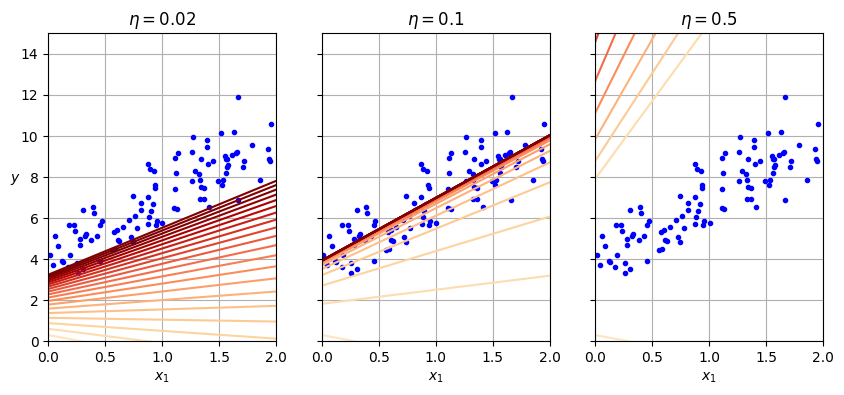

In [11]:
# extra code – generates Figure 4–8

import matplotlib as mpl

def plot_gradient_descent(theta, eta):
    m = len(X_b)
    plt.plot(X, y, "b.")
    n_epochs = 1000
    n_shown = 20
    theta_path = []
    for epoch in range(n_epochs):
        if epoch < n_shown:
            y_predict = X_new_b @ theta
            color = mpl.colors.rgb2hex(plt.cm.OrRd(epoch / n_shown + 0.15))
            plt.plot(X_new, y_predict, linestyle="solid", color=color)
        gradients = 2 / m * X_b.T @ (X_b @ theta - y)
        theta = theta - eta * gradients
        theta_path.append(theta)
    plt.xlabel("$x_1$")
    plt.axis([0, 2, 0, 15])
    plt.grid()
    plt.title(fr"$\eta = {eta}$")
    return theta_path

rng = np.random.default_rng(seed=42)
theta = rng.standard_normal((2, 1))  # randomly initialized model parameters

plt.figure(figsize=(10, 4))
plt.subplot(131)
plot_gradient_descent(theta, eta=0.02)
plt.ylabel("$y$", rotation=0)
plt.subplot(132)
theta_path_bgd = plot_gradient_descent(theta, eta=0.1)
plt.gca().axes.yaxis.set_ticklabels([])
plt.subplot(133)
plt.gca().axes.yaxis.set_ticklabels([])
plot_gradient_descent(theta, eta=0.5)

plt.show()

## Stochastic Gradient Descent (SGD)

In [12]:
n_epochs = 50
t0, t1 = 5, 50  # learning schedule hyperparameters

def learning_schedule(t):
    return t0 / (t + t1)

rng = np.random.default_rng(seed=42)
theta = rng.standard_normal((2, 1))  # randomly initialized model parameters

for epoch in range(n_epochs):
    for iteration in range(m):
        random_index = rng.integers(m)
        xi = X_b[random_index:random_index + 1]
        yi = y[random_index:random_index + 1]
        gradients = 2 * xi.T @ (xi @ theta - yi)
        eta = learning_schedule(epoch * m + iteration)
        theta = theta - eta * gradients

theta

array([[3.966486  ],
       [3.04565621]])

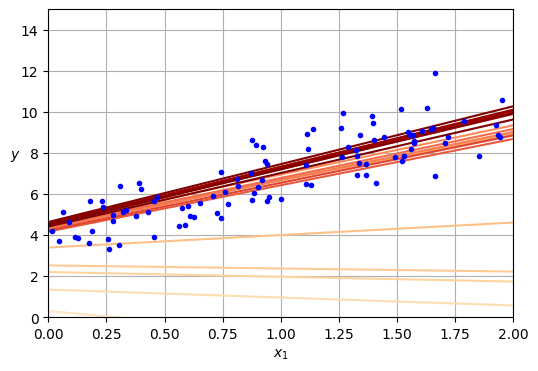

In [13]:
n_epochs = 50
t0, t1 = 5, 50  # learning schedule hyperparameters

theta_path_sgd = []

def learning_schedule(t):
    return t0 / (t + t1)

rng = np.random.default_rng(seed=42)
theta = rng.standard_normal((2, 1))  # randomly initialized model parameters

n_shown = 20  # extra code – just needed to generate the figure below
plt.figure(figsize=(6, 4))  # extra code – not needed, just formatting

for epoch in range(n_epochs):
    for iteration in range(m):

        # extra code – these 4 lines are used to generate the figure
        if epoch == 0 and iteration < n_shown:
            y_predict = X_new_b @ theta
            color = mpl.colors.rgb2hex(plt.cm.OrRd(iteration / n_shown + 0.15))
            plt.plot(X_new, y_predict, color=color)

        random_index = rng.integers(m)
        xi = X_b[random_index : random_index + 1]
        yi = y[random_index : random_index + 1]
        gradients = 2 * xi.T @ (xi @ theta - yi)  # for SGD, do not divide by m
        eta = learning_schedule(epoch * m + iteration)  # learning rate
        theta = theta - eta * gradients
        theta_path_sgd.append(theta)  # extra code – to generate the figure

# extra code – this section beautifies Figure 4–10
plt.plot(X, y, "b.")
plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.axis([0, 2, 0, 15])
plt.grid()

plt.show()

In [14]:
from sklearn.linear_model import SGDRegressor

sdg_reg = SGDRegressor(max_iter=1000, tol=1e-5, penalty=None, eta0=0.1,
                        n_iter_no_change=100, random_state=42)

sdg_reg.fit(X, y.ravel())
sdg_reg.intercept_, sdg_reg.coef_

(array([3.92760553]), array([3.00157861]))

## Mini-batch gradient descent

The code in this section is used to generate the next figure, it is not in the book.

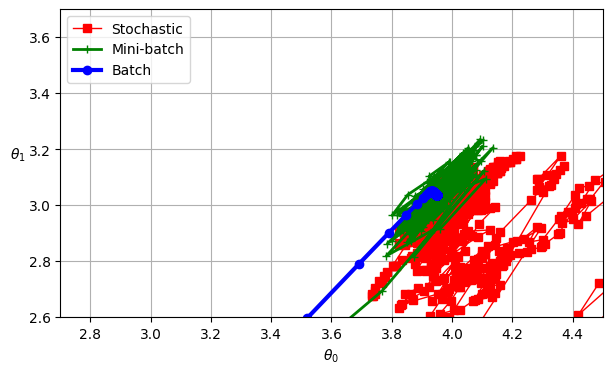

In [15]:
# extra code – this cell generates Figure 4–11

from math import ceil

n_epochs = 50
minibatch_size = 20
n_batches_per_epoch = ceil(m / minibatch_size)

rng = np.random.default_rng(seed=42)
theta = rng.standard_normal((2, 1))  # randomly initialized model parameters

t0, t1 = 200, 1000  # learning schedule hyperparameters

def learning_schedule(t):
    return t0 / (t + t1)

theta_path_mgd = []
for epoch in range(n_epochs):
    shuffled_indices = rng.permutation(m)
    X_b_shuffled = X_b[shuffled_indices]
    y_shuffled = y[shuffled_indices]
    for iteration in range(0, n_batches_per_epoch):
        idx = iteration * minibatch_size
        xi = X_b_shuffled[idx : idx + minibatch_size]
        yi = y_shuffled[idx : idx + minibatch_size]
        gradients = 2 / minibatch_size * xi.T @ (xi @ theta - yi)
        eta = learning_schedule(epoch * n_batches_per_epoch + iteration)
        theta = theta - eta * gradients
        theta_path_mgd.append(theta)

theta_path_bgd = np.array(theta_path_bgd)
theta_path_sgd = np.array(theta_path_sgd)
theta_path_mgd = np.array(theta_path_mgd)

plt.figure(figsize=(7, 4))
plt.plot(theta_path_sgd[:, 0], theta_path_sgd[:, 1], "r-s", linewidth=1,
         label="Stochastic")
plt.plot(theta_path_mgd[:, 0], theta_path_mgd[:, 1], "g-+", linewidth=2,
         label="Mini-batch")
plt.plot(theta_path_bgd[:, 0], theta_path_bgd[:, 1], "b-o", linewidth=3,
         label="Batch")
plt.legend(loc="upper left")
plt.xlabel(r"$\theta_0$")
plt.ylabel(r"$\theta_1$   ", rotation=0)
plt.axis([2.7, 4.5, 2.6, 3.7])
plt.grid()

plt.show()

## Polynomial regression

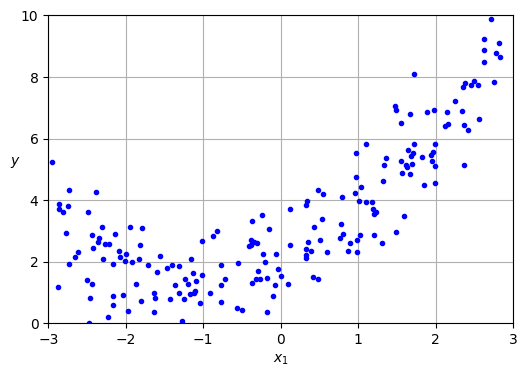

In [16]:
rng = np.random.default_rng(seed=42)
m = 200 # number of instances
X = 6 * rng.random((m, 1)) - 3
y = 0.5 * X ** 2 + X + 2 + rng.standard_normal((m, 1))

# plot 
plt.figure(figsize=(6, 4))
plt.plot(X, y, "b.")
plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.axis([-3, 3, 0, 10])
plt.grid()
plt.show()


In [17]:
from sklearn.preprocessing import PolynomialFeatures
poly_features = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly_features.fit_transform(X)
X_poly[:5]

array([[ 1.64373629,  2.701869  ],
       [-0.36672936,  0.13449042],
       [ 2.15158752,  4.62932885],
       [ 1.18420817,  1.402349  ],
       [-2.43493591,  5.9289129 ]])

In [18]:
X[:5]

array([[ 1.64373629],
       [-0.36672936],
       [ 2.15158752],
       [ 1.18420817],
       [-2.43493591]])

In [19]:
lin_reg = LinearRegression()
lin_reg.fit(X_poly, y)
lin_reg.intercept_, lin_reg.coef_


(array([2.00540719]), array([[1.11022126, 0.50526985]]))

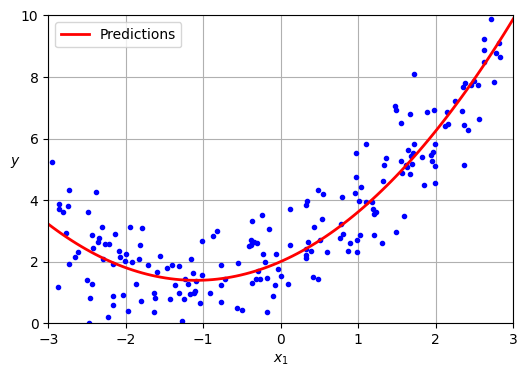

In [20]:
# extra code – this cell generates Figure 4–13

X_new = np.linspace(-3, 3, 100).reshape(100, 1)
X_new_poly = poly_features.transform(X_new)
y_new = lin_reg.predict(X_new_poly)

plt.figure(figsize=(6, 4))
plt.plot(X, y, "b.")
plt.plot(X_new, y_new, "r-", linewidth=2, label="Predictions")
plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.legend(loc="upper left")
plt.axis([-3, 3, 0, 10])
plt.grid()

plt.show()

## Learning Curves

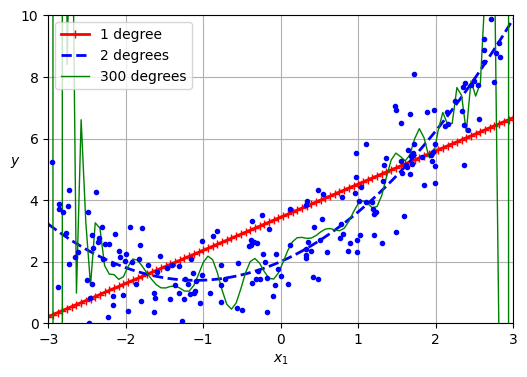

In [21]:
# extra code – this cell generates Figure 4–14

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

plt.figure(figsize=(6, 4))

for style, width, degree in (("r-+", 2, 1), ("b--", 2, 2), ("g-", 1, 300)):
    polybig_features = PolynomialFeatures(degree=degree, include_bias=False)
    std_scaler = StandardScaler()
    lin_reg = LinearRegression()
    polynomial_regression = make_pipeline(polybig_features, std_scaler, lin_reg)
    polynomial_regression.fit(X, y)
    y_newbig = polynomial_regression.predict(X_new)
    label = f"{degree} degree{'s' if degree > 1 else ''}"
    plt.plot(X_new, y_newbig, style, label=label, linewidth=width)

plt.plot(X, y, "b.", linewidth=3)
plt.legend(loc="upper left")
plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.axis([-3, 3, 0, 10])
plt.grid()

plt.show()

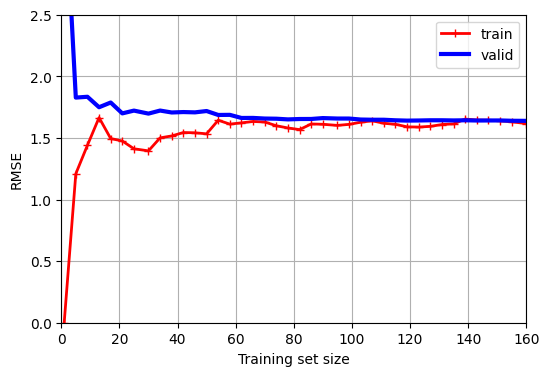

In [22]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, valid_scores = learning_curve(
    LinearRegression(), X, y, train_sizes=np.linspace(0.01, 1.0, 40), cv=5,
    scoring="neg_root_mean_squared_error")
train_errors = -train_scores.mean(axis=1)
valid_errors = -valid_scores.mean(axis=1)

plt.figure(figsize=(6, 4))  # extra code – not needed, just formatting
plt.plot(train_sizes, train_errors, "r-+", linewidth=2, label="train")
plt.plot(train_sizes, valid_errors, "b-", linewidth=3, label="valid")

# extra code – beautifies Figure 4–15
plt.xlabel("Training set size")
plt.ylabel("RMSE")
plt.grid()
plt.legend(loc="upper right")
plt.axis([0, 160, 0, 2.5])

plt.show()

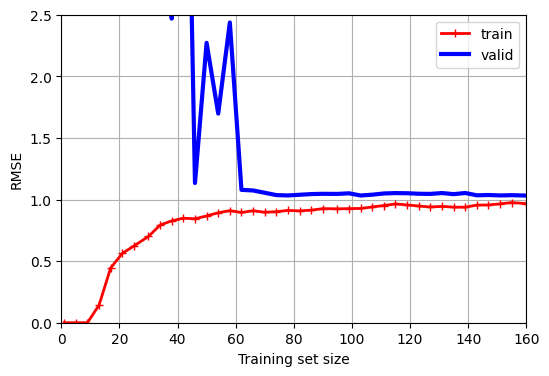

In [23]:
from sklearn.pipeline import make_pipeline

polynomial_regression = make_pipeline(PolynomialFeatures(degree=10, include_bias=False),
                                      LinearRegression())

train_sizes, train_scores, valid_scores = learning_curve(
    polynomial_regression, X, y, train_sizes=np.linspace(0.01, 1.0, 40), cv=5, scoring="neg_root_mean_squared_error")

train_errors = -train_scores.mean(axis=1)
valid_errors = -valid_scores.mean(axis=1)

plt.figure(figsize=(6, 4))  # extra code – not needed, just formatting
plt.plot(train_sizes, train_errors, "r-+", linewidth=2, label="train")
plt.plot(train_sizes, valid_errors, "b-", linewidth=3, label="valid")
plt.xlabel("Training set size")
plt.ylabel("RMSE")
plt.grid()
plt.legend(loc="upper right")
plt.axis([0, 160, 0, 2.5])
plt.show()

## Ridge Regression

La función de costo de Ridge Regression se define como:

$$
J(\theta) = \text{MSE}(\theta) + \frac{\alpha}{m} \sum_{i=1}^{n} \theta_i^2
$$

#### Donde:
- $J(\theta)$: Función de costo total  
- $\text{MSE}(\theta)$: Error cuadrático medio  
- $\alpha$: Parámetro de regularización (controla qué tanto penalizas los pesos)  
- $m$: Número de muestras  
- $n$: Número de características  
- $\theta_i$: Parámetros del modelo (excepto el bias, normalmente)  

#### Intuición:
Ridge Regression añade una penalización al tamaño de los coeficientes para evitar overfitting, favoreciendo valores pequeños en $\theta$.

In [24]:
# extra code – we've done this type of generation several times before
rng = np.random.default_rng(seed=42)
m = 20  # number of instances
X = 3 * rng.random((m, 1))
y = 1 + 0.5 * X + rng.standard_normal((m, 1)) / 1.5
X_new = np.linspace(0, 3, 100).reshape(100, 1)

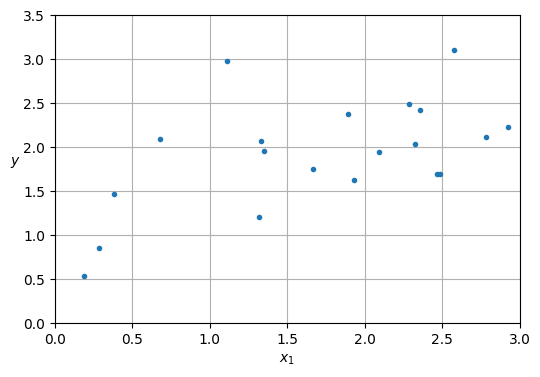

In [25]:
# extra code – a quick peek at the dataset we just generated
plt.figure(figsize=(6, 4))
plt.plot(X, y, ".")
plt.xlabel("$x_1$")
plt.ylabel("$y$  ", rotation=0)
plt.axis([0, 3, 0, 3.5])
plt.grid()
plt.show()

In [26]:
from sklearn.linear_model import Ridge

ridge_reg = Ridge(alpha=0.1, solver="cholesky")
ridge_reg.fit(X, y)
ridge_reg.predict([[1.5]])

array([1.84414523])

In [27]:
ridge_reg.coef_, ridge_reg.intercept_

(array([0.40443361]), array([1.23749481]))

La solución analítica de Ridge Regression está dada por:

$$
\theta = \left( X^\top X + \alpha A \right)^{-1} X^\top y
$$

#### Donde:
- $\theta$: Vector de parámetros óptimos  
- $X$: Matriz de características (features)  
- $X^\top$: Transpuesta de $X$  
- $y$: Vector de valores objetivo  
- $\alpha$: Parámetro de regularización  
- $A$: Matriz identidad modificada (usualmente con 0 en la posición del bias para no regularizarlo)

#### Nota:
Esta solución es una extensión de la ecuación normal de regresión lineal, agregando regularización para mejorar la estabilidad numérica y reducir overfitting.

In [28]:
alpha = 0.1
X_b = add_dummy_feature(X)  # agrega una columna de 1s para el término de sesgo
n_features = X_b.shape[1]
A = np.eye(n_features)  # matriz identidad de tamaño n_features x n_features
A[0, 0] = 0  # no regularizamos el término de sesgo
theta_best = np.linalg.inv(X_b.T @ X_b + alpha * np.eye(n_features)) @ X_b.T @ y
theta_best

array([[1.2058362 ],
       [0.41932123]])

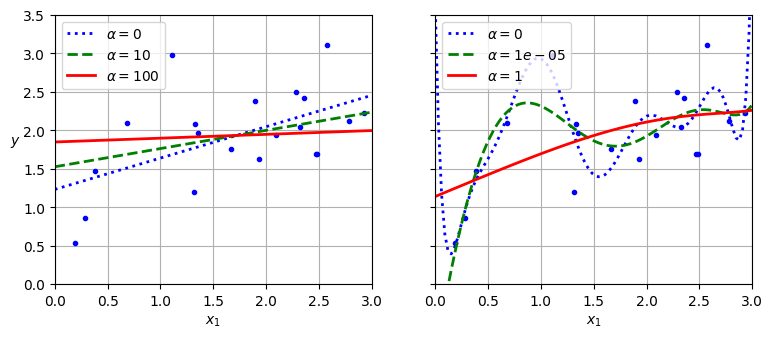

In [29]:
# extra code – this cell generates Figure 4–17

def plot_model(model_class, polynomial, alphas, **model_kwargs):
    plt.plot(X, y, "b.", linewidth=3)
    for alpha, style in zip(alphas, ("b:", "g--", "r-")):
        if alpha > 0:
            model = model_class(alpha, **model_kwargs)
        else:
            model = LinearRegression()
        if polynomial:
            model = make_pipeline(
                PolynomialFeatures(degree=10, include_bias=False),
                StandardScaler(),
                model)
        model.fit(X, y)
        y_new_regul = model.predict(X_new)
        plt.plot(X_new, y_new_regul, style, linewidth=2,
                 label=fr"$\alpha = {alpha}$")
    plt.legend(loc="upper left")
    plt.xlabel("$x_1$")
    plt.axis([0, 3, 0, 3.5])
    plt.grid()

plt.figure(figsize=(9, 3.5))
plt.subplot(121)
plot_model(Ridge, polynomial=False, alphas=(0, 10, 100), random_state=42)
plt.ylabel("$y$  ", rotation=0)
plt.subplot(122)
plot_model(Ridge, polynomial=True, alphas=(0, 10**-5, 1), random_state=42)
plt.gca().axes.yaxis.set_ticklabels([])

plt.show()

In [30]:
sdg_reg = SGDRegressor(penalty="l2", alpha=0.1/m, max_iter=1000, tol=None, eta0=0.01,
                        n_iter_no_change=100, random_state=42)

sdg_reg.fit(X, y.ravel())
sdg_reg.intercept_, sdg_reg.coef_

(array([1.21192021]), array([0.41645124]))

In [31]:
sdg_reg.predict([[1.5]])

array([1.83659707])

## Lasso Regression

In [32]:
from sklearn.linear_model import Lasso

lasso_reg = Lasso(alpha=0.1)
lasso_reg.fit(X, y)
lasso_reg.intercept_, lasso_reg.coef_
lasso_reg.predict([[1.5]])


array([1.87550211])

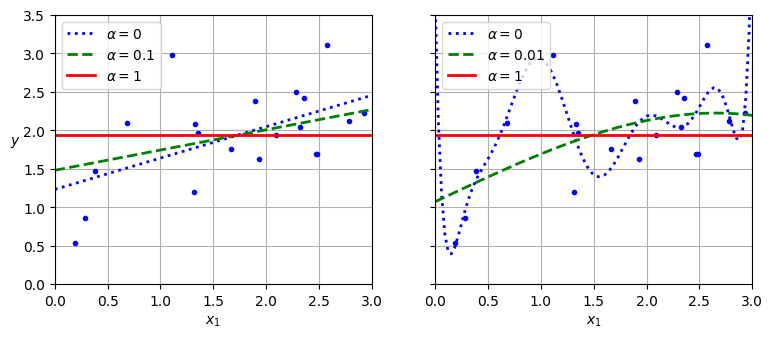

In [34]:
# extra code – this cell generates Figure 4–18
plt.figure(figsize=(9, 3.5))
plt.subplot(121)
plot_model(Lasso, polynomial=False, alphas=(0, 0.1, 1), random_state=42)
plt.ylabel("$y$  ", rotation=0)
plt.subplot(122)
plot_model(Lasso, polynomial=True, alphas=(0, 1e-2, 1), random_state=42)
plt.gca().axes.yaxis.set_ticklabels([])

plt.show()

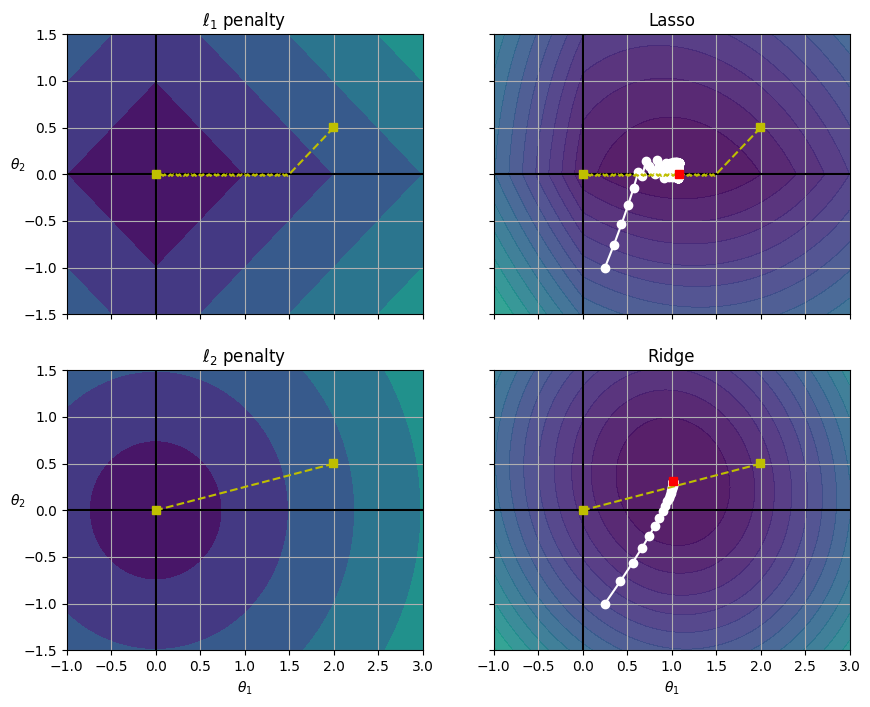

In [35]:
# extra code – this BIG cell generates Figure 4–19

t1a, t1b, t2a, t2b = -1, 3, -1.5, 1.5

t1s = np.linspace(t1a, t1b, 500)
t2s = np.linspace(t2a, t2b, 500)
t1, t2 = np.meshgrid(t1s, t2s)
T = np.c_[t1.ravel(), t2.ravel()]
Xr = np.array([[1, 1], [1, -1], [1, 0.5]])
yr = 2 * Xr[:, :1] + 0.5 * Xr[:, 1:]

J = (1 / len(Xr) * ((T @ Xr.T - yr.T) ** 2).sum(axis=1)).reshape(t1.shape)

N1 = np.linalg.norm(T, ord=1, axis=1).reshape(t1.shape)
N2 = np.linalg.norm(T, ord=2, axis=1).reshape(t1.shape)

t_min_idx = np.unravel_index(J.argmin(), J.shape)
t1_min, t2_min = t1[t_min_idx], t2[t_min_idx]

t_init = np.array([[0.25], [-1]])

def bgd_path(theta, X, y, l1, l2, core=1, eta=0.05, n_iterations=200):
    path = [theta]
    for iteration in range(n_iterations):
        gradients = (core * 2 / len(X) * X.T @ (X @ theta - y)
                     + l1 * np.sign(theta) + l2 * theta)
        theta = theta - eta * gradients
        path.append(theta)
    return np.array(path)

fig, axes = plt.subplots(2, 2, sharex=True, sharey=True, figsize=(10.1, 8))

for i, N, l1, l2, title in ((0, N1, 2.0, 0, "Lasso"), (1, N2, 0, 2.0, "Ridge")):
    JR = J + l1 * N1 + l2 * 0.5 * N2 ** 2

    tr_min_idx = np.unravel_index(JR.argmin(), JR.shape)
    t1r_min, t2r_min = t1[tr_min_idx], t2[tr_min_idx]

    levels = np.exp(np.linspace(0, 1, 20)) - 1
    levelsJ = levels * (J.max() - J.min()) + J.min()
    levelsJR = levels * (JR.max() - JR.min()) + JR.min()
    levelsN = np.linspace(0, N.max(), 10)

    path_J = bgd_path(t_init, Xr, yr, l1=0, l2=0)
    path_JR = bgd_path(t_init, Xr, yr, l1, l2)
    path_N = bgd_path(theta=np.array([[2.0], [0.5]]), X=Xr, y=yr,
                      l1=np.sign(l1) / 3, l2=np.sign(l2), core=0)
    ax = axes[i, 0]
    ax.grid()
    ax.axhline(y=0, color="k")
    ax.axvline(x=0, color="k")
    ax.contourf(t1, t2, N / 2.0, levels=levelsN)
    ax.plot(path_N[:, 0], path_N[:, 1], "y--")
    ax.plot(0, 0, "ys")
    ax.plot(t1_min, t2_min, "ys")
    ax.set_title(fr"$\ell_{i + 1}$ penalty")
    ax.axis([t1a, t1b, t2a, t2b])
    if i == 1:
        ax.set_xlabel(r"$\theta_1$")
    ax.set_ylabel(r"$\theta_2$", rotation=0)

    ax = axes[i, 1]
    ax.grid()
    ax.axhline(y=0, color="k")
    ax.axvline(x=0, color="k")
    ax.contourf(t1, t2, JR, levels=levelsJR, alpha=0.9)
    ax.plot(path_JR[:, 0], path_JR[:, 1], "w-o")
    ax.plot(path_N[:, 0], path_N[:, 1], "y--")
    ax.plot(0, 0, "ys")
    ax.plot(t1_min, t2_min, "ys")
    ax.plot(t1r_min, t2r_min, "rs")
    ax.set_title(title)
    ax.axis([t1a, t1b, t2a, t2b])
    if i == 1:
        ax.set_xlabel(r"$\theta_1$")

plt.show()

La función de costo de Lasso no es diferenciable en $\theta_i = 0$ (para $i = 1, 2, \dots, n$).  
Sin embargo, *gradient descent* sigue funcionando si se utiliza un subgradiente.

---

### Subgradiente de Lasso

$$
\mathbf{g}(\boldsymbol{\theta}) 
= \nabla_{\boldsymbol{\theta}} \, \mathrm{MSE}(\boldsymbol{\theta}) 
+ 2\alpha 
\begin{bmatrix}
\mathrm{sign}(\theta_1) \\
\mathrm{sign}(\theta_2) \\
\vdots \\
\mathrm{sign}(\theta_n)
\end{bmatrix}
$$

---

### Función signo

$$
\mathrm{sign}(\theta_i) =
\begin{cases}
-1 & \text{si } \theta_i < 0 \\
0  & \text{si } \theta_i = 0 \\
+1 & \text{si } \theta_i > 0
\end{cases}
$$

---

### Nota

- Cuando $\theta_i = 0$, el gradiente no está definido, pero cualquier valor en el rango $[-1, 1]$ es un subgradiente válido.  
- En la práctica, se suele usar $0$ por estabilidad numérica.

In [36]:
from sklearn.linear_model import Lasso

lasso_reg = Lasso(alpha=0.1)
lasso_reg.fit(X, y)
lasso_reg.predict([[1.5]])

array([1.87550211])

In [ ]:
sdg_reg = SGDRegressor(penalty='l1', alpha=0.1)
sdg_reg.fit(X, y.ravel())
sdg_reg.predict([[1.5]])

array([1.64805535])

## Elastic Net Regression

La función de costo de Elastic Net combina las penalizaciones de Lasso (L1) y Ridge (L2):

$$
J(\boldsymbol{\theta}) = \mathrm{MSE}(\boldsymbol{\theta})
+ r \, 2\alpha \sum_{i=1}^{n} |\theta_i|
+ (1 - r)\, \frac{\alpha}{m} \sum_{i=1}^{n} \theta_i^2
$$

---

### Parámetros

- $r$: controla la mezcla entre Lasso y Ridge  
  - $r = 1$ → Lasso  
  - $r = 0$ → Ridge  
- $\alpha$: intensidad de la regularización  
- $m$: número de muestras  
- $n$: número de variables

---

### Nota

- El término $|\theta_i|$ corresponde a la regularización L1 (Lasso).
- El término $\theta_i^2$ corresponde a la regularización L2 (Ridge).

In [39]:
from sklearn.linear_model import ElasticNet

elastic_net = ElasticNet(alpha=0.1, l1_ratio=0.5)
elastic_net.fit(X, y)
elastic_net.predict([[1.5]])

array([1.8645014])

## Early Stopping

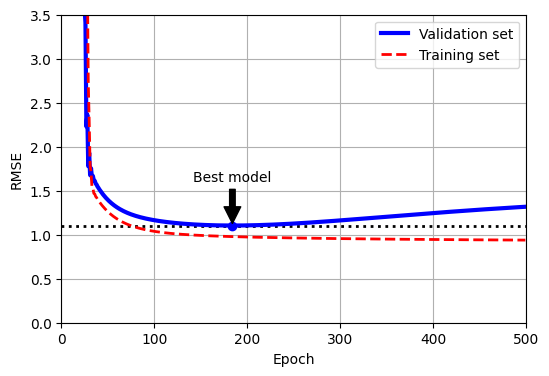

In [40]:
from copy import deepcopy
from sklearn.metrics import root_mean_squared_error
from sklearn.preprocessing import StandardScaler

# extra code – creates the same quadratic dataset as earlier and splits it
rng = np.random.default_rng(seed=42)
m = 200  # number of instances
X = 6 * rng.random((m, 1)) - 3
y = 0.5 * X ** 2 + X + 2 + rng.standard_normal((m, 1))
X_train, y_train = X[: m // 2], y[: m // 2, 0]
X_valid, y_valid = X[m // 2 :], y[m // 2 :, 0]

preprocessing = make_pipeline(PolynomialFeatures(degree=90, include_bias=False),
                              StandardScaler())
X_train_prep = preprocessing.fit_transform(X_train)
X_valid_prep = preprocessing.transform(X_valid)
sgd_reg = SGDRegressor(penalty=None, eta0=0.002, random_state=42)
n_epochs = 500
best_valid_rmse = float('inf')
train_errors, val_errors = [], []  # extra code – it's for the figure below

for epoch in range(n_epochs):
    sgd_reg.partial_fit(X_train_prep, y_train)
    y_valid_predict = sgd_reg.predict(X_valid_prep)
    val_error = root_mean_squared_error(y_valid, y_valid_predict)
    if val_error < best_valid_rmse:
        best_valid_rmse = val_error
        best_model = deepcopy(sgd_reg)

    # extra code – we evaluate the train error and save it for the figure
    y_train_predict = sgd_reg.predict(X_train_prep)
    train_error = root_mean_squared_error(y_train, y_train_predict)
    val_errors.append(val_error)
    train_errors.append(train_error)

# extra code – this section generates Figure 4–20
best_epoch = np.argmin(val_errors)
plt.figure(figsize=(6, 4))
plt.annotate('Best model',
             xy=(best_epoch, best_valid_rmse),
             xytext=(best_epoch, best_valid_rmse + 0.5),
             ha="center",
             arrowprops=dict(facecolor='black', shrink=0.05))
plt.plot([0, n_epochs], [best_valid_rmse, best_valid_rmse], "k:", linewidth=2)
plt.plot(val_errors, "b-", linewidth=3, label="Validation set")
plt.plot(best_epoch, best_valid_rmse, "bo")
plt.plot(train_errors, "r--", linewidth=2, label="Training set")
plt.legend(loc="upper right")
plt.xlabel("Epoch")
plt.ylabel("RMSE")
plt.axis([0, n_epochs, 0, 3.5])
plt.grid()

plt.show()

## Logistic Regression
### Estimating Probabilities